# CLIP CUB-200 Corruption Confidence Probe

기본 OpenAI CLIP으로 CUB-200 샘플 몇 장을 뽑아 원본과 corruption 적용 후 confidence 변화를 관찰합니다.

- `data/cub200_prepared/test`의 클래스 폴더 구조를 그대로 사용합니다.
- MacBook에서는 `mps`를 우선 사용하고, 없으면 `cuda`/`cpu`로 fallback합니다.
- 결과 테이블, confidence 변화, overconfidence 후보, hub-like 오분류 집중 클래스를 노트북 안에서 바로 확인합니다.

In [1]:
from pathlib import Path
import random
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

try:
    import open_clip
except ImportError as exc:
    raise ImportError("open_clip_torch가 필요합니다. repo root에서 `pip install -r requirements.txt` 실행 후 다시 시도하세요.") from exc

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "utils" / "corruptions.py").exists():
    REPO_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(REPO_ROOT))

from utils.corruptions import apply_corruption

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 설정

`N_SAMPLES`, `CORRUPTION`, `SEVERITY`만 바꾸면 빠르게 다른 조건을 볼 수 있습니다.

In [2]:
DATA_ROOT = REPO_ROOT / "data" / "cub200_prepared"
SPLIT = "test"
N_SAMPLES = 24
SEED = 7

# utils/corruptions.py 지원 목록:
# gaussian_noise, motion_blur, brightness, contrast, jpeg_compression, downsample_upsample
CORRUPTION = "gaussian_noise"
SEVERITY = 3

MODEL_NAME = "ViT-B-32"
PRETRAINED = "openai"
TOPK = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

DEVICE

device(type='mps')

In [3]:
def cub_folder_to_label(folder_name: str) -> str:
    # e.g. 005.Crested_Auklet -> crested auklet
    name = folder_name.split(".", 1)[1] if "." in folder_name else folder_name
    return name.replace("_", " ").lower()


def collect_cub_images(root: Path, split: str):
    split_dir = root / split
    if not split_dir.exists():
        raise FileNotFoundError(f"CUB split 경로가 없습니다: {split_dir}")

    class_dirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])
    classes = [cub_folder_to_label(p.name) for p in class_dirs]
    records = []
    for class_dir, label in zip(class_dirs, classes):
        for path in sorted(class_dir.iterdir()):
            if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                records.append({"path": path, "true_label": label, "class_dir": class_dir.name})
    return classes, records


classes, image_records = collect_cub_images(DATA_ROOT, SPLIT)
print(f"classes: {len(classes)}")
print(f"images found: {len(image_records)}")
print(f"data split: {DATA_ROOT / SPLIT}")

if len(image_records) == 0:
    raise RuntimeError("이미지 파일을 찾지 못했습니다. symlink target이 살아있는지, DATA_ROOT/SPLIT 설정이 맞는지 확인하세요.")

sample_records = random.sample(image_records, k=min(N_SAMPLES, len(image_records)))
pd.DataFrame(sample_records).head()

classes: 200
images found: 5794
data split: /Users/taehayeong/Desktop/Git_workspace/lab/data/cub200_prepared/test


,path,true_label,class_dir
0,/Users/taehayeong/Desktop/Git_workspace/lab/da...,clark nutcracker,093.Clark_Nutcracker
1,/Users/taehayeong/Desktop/Git_workspace/lab/da...,northern fulmar,045.Northern_Fulmar
2,/Users/taehayeong/Desktop/Git_workspace/lab/da...,black throated sparrow,114.Black_throated_Sparrow
3,/Users/taehayeong/Desktop/Git_workspace/lab/da...,bohemian waxwing,185.Bohemian_Waxwing
4,/Users/taehayeong/Desktop/Git_workspace/lab/da...,painted bunting,016.Painted_Bunting


In [4]:
model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME,
    pretrained=PRETRAINED,
    device=DEVICE,
)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)
model.eval()

prompts = [f"a photo of a {label}, a type of bird" for label in classes]
text_tokens = tokenizer(prompts).to(DEVICE)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print(f"Loaded {MODEL_NAME}/{PRETRAINED} on {DEVICE}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded ViT-B-32/openai on mps


In [5]:
def predict_pil(image: Image.Image):
    image_tensor = preprocess(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        image_features = model.encode_image(image_tensor)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = (100.0 * image_features @ text_features.T).float()
        probs = logits.softmax(dim=-1).squeeze(0).detach().cpu()

    top_probs, top_indices = torch.topk(probs, k=TOPK)
    top = [(classes[int(idx)], float(prob)) for prob, idx in zip(top_probs, top_indices)]
    return {
        "pred_label": top[0][0],
        "confidence": top[0][1],
        "topk": top,
    }


rows = []
preview_images = []

for sample_id, record in enumerate(sample_records):
    image = Image.open(record["path"]).convert("RGB")
    corrupted = apply_corruption(image, CORRUPTION, SEVERITY)

    original_pred = predict_pil(image)
    corrupted_pred = predict_pil(corrupted)

    for condition, pil_image, pred in [
        ("clean", image, original_pred),
        (f"{CORRUPTION}_s{SEVERITY}", corrupted, corrupted_pred),
    ]:
        rows.append({
            "sample_id": sample_id,
            "condition": condition,
            "path": str(record["path"]),
            "true_label": record["true_label"],
            "pred_label": pred["pred_label"],
            "confidence": pred["confidence"],
            "correct": pred["pred_label"] == record["true_label"],
            "topk": pred["topk"],
        })

    preview_images.append({
        "sample_id": sample_id,
        "true_label": record["true_label"],
        "clean_image": image,
        "corrupted_image": corrupted,
        "clean_pred": original_pred,
        "corrupted_pred": corrupted_pred,
    })

df = pd.DataFrame(rows)
wide = df.pivot(index="sample_id", columns="condition", values=["pred_label", "confidence", "correct"])
wide.columns = ["_".join(map(str, col)).strip() for col in wide.columns]
wide = wide.reset_index().merge(df[df.condition == "clean"][["sample_id", "true_label", "path"]], on="sample_id")

corr_condition = f"{CORRUPTION}_s{SEVERITY}"
wide["correct_clean"] = wide["correct_clean"].astype(bool)
wide[f"correct_{corr_condition}"] = wide[f"correct_{corr_condition}"].astype(bool)
wide["confidence_delta"] = wide[f"confidence_{corr_condition}"] - wide["confidence_clean"]
wide["became_wrong"] = wide["correct_clean"] & (~wide[f"correct_{corr_condition}"])
wide["overconfidence_candidate"] = (~wide[f"correct_{corr_condition}"]) & (wide["confidence_delta"] > 0)

summary = pd.DataFrame({
    "condition": ["clean", corr_condition],
    "accuracy": [df[df.condition == "clean"].correct.mean(), df[df.condition == corr_condition].correct.mean()],
    "mean_confidence": [df[df.condition == "clean"].confidence.mean(), df[df.condition == corr_condition].confidence.mean()],
    "median_confidence": [df[df.condition == "clean"].confidence.median(), df[df.condition == corr_condition].confidence.median()],
})
summary

,condition,accuracy,mean_confidence,median_confidence
0,clean,0.458333,0.391922,0.286723
1,gaussian_noise_s3,0.333333,0.355339,0.252167


In [6]:
display_cols = [
    "sample_id",
    "true_label",
    "pred_label_clean",
    "confidence_clean",
    f"pred_label_{corr_condition}",
    f"confidence_{corr_condition}",
    "confidence_delta",
    "became_wrong",
    "overconfidence_candidate",
]

wide[display_cols].sort_values("confidence_delta", ascending=False).style.format({
    "confidence_clean": "{:.3f}",
    f"confidence_{corr_condition}": "{:.3f}",
    "confidence_delta": "{:+.3f}",
})

,sample_id,true_label,pred_label_clean,confidence_clean,pred_label_gaussian_noise_s3,confidence_gaussian_noise_s3,confidence_delta,became_wrong,overconfidence_candidate
10,10,gray catbird,gray catbird,0.623,gray catbird,0.824,+0.201,False,False
4,4,painted bunting,painted bunting,0.667,painted bunting,0.850,+0.183,False,False
0,0,clark nutcracker,ivory gull,0.168,clark nutcracker,0.279,+0.111,False,False
23,23,blue winged warbler,kentucky warbler,0.271,kentucky warbler,0.370,+0.099,False,True
22,22,gray catbird,gray catbird,0.840,gray catbird,0.922,+0.081,False,False
5,5,brandt cormorant,pelagic cormorant,0.312,whip poor will,0.380,+0.068,False,True
18,18,green violetear,green violetear,0.744,green violetear,0.798,+0.054,False,False
14,14,shiny cowbird,brewer blackbird,0.173,fish crow,0.226,+0.053,False,True
16,16,fox sparrow,sage thrasher,0.070,fox sparrow,0.120,+0.050,False,False
20,20,yellow throated vireo,yellow throated vireo,0.156,kentucky warbler,0.201,+0.045,True,True


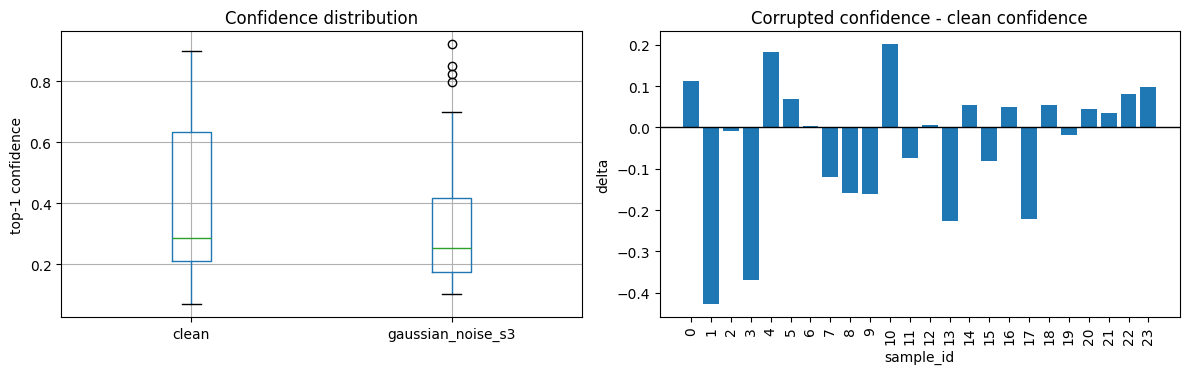

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column="confidence", by="condition", ax=axes[0])
axes[0].set_title("Confidence distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("top-1 confidence")

axes[1].axhline(0, color="black", linewidth=1)
axes[1].bar(wide["sample_id"].astype(str), wide["confidence_delta"])
axes[1].set_title("Corrupted confidence - clean confidence")
axes[1].set_xlabel("sample_id")
axes[1].set_ylabel("delta")
axes[1].tick_params(axis="x", rotation=90)

plt.suptitle("")
plt.tight_layout()
plt.show()

## Overconfidence와 hub-like 오분류

`overconfidence_candidate`는 corrupted prediction이 틀렸고 원본보다 confidence가 증가한 경우입니다. Hub-like 현상은 corrupted 오분류가 특정 predicted class로 얼마나 몰리는지 간단히 집계합니다.

In [8]:
overconf = wide[wide["overconfidence_candidate"]].copy()
print(f"overconfidence candidates: {len(overconf)} / {len(wide)}")
display(overconf[display_cols].sort_values("confidence_delta", ascending=False).style.format({
    "confidence_clean": "{:.3f}",
    f"confidence_{corr_condition}": "{:.3f}",
    "confidence_delta": "{:+.3f}",
}))

corrupted_wrong = df[(df.condition == corr_condition) & (~df.correct)].copy()
hub = (
    corrupted_wrong.groupby("pred_label")
    .agg(count=("pred_label", "size"), mean_confidence=("confidence", "mean"))
    .sort_values(["count", "mean_confidence"], ascending=False)
    .reset_index()
)
display(hub.head(20).style.format({"mean_confidence": "{:.3f}"}))

overconfidence candidates: 7 / 24


,sample_id,true_label,pred_label_clean,confidence_clean,pred_label_gaussian_noise_s3,confidence_gaussian_noise_s3,confidence_delta,became_wrong,overconfidence_candidate
23,23,blue winged warbler,kentucky warbler,0.271,kentucky warbler,0.370,+0.099,False,True
5,5,brandt cormorant,pelagic cormorant,0.312,whip poor will,0.380,+0.068,False,True
14,14,shiny cowbird,brewer blackbird,0.173,fish crow,0.226,+0.053,False,True
20,20,yellow throated vireo,yellow throated vireo,0.156,kentucky warbler,0.201,+0.045,True,True
21,21,harris sparrow,field sparrow,0.121,nelson sharp tailed sparrow,0.156,+0.035,False,True
12,12,ivory gull,ivory gull,0.333,glaucous winged gull,0.339,+0.006,True,True
6,6,philadelphia vireo,white eyed vireo,0.110,common yellowthroat,0.113,+0.002,False,True


,pred_label,count,mean_confidence
0,glaucous winged gull,2,0.287
1,kentucky warbler,2,0.285
2,whip poor will,1,0.380
3,boat tailed grackle,1,0.277
4,white crowned sparrow,1,0.270
5,fish crow,1,0.226
6,song sparrow,1,0.191
7,forsters tern,1,0.189
8,pacific loon,1,0.183
9,nelson sharp tailed sparrow,1,0.156


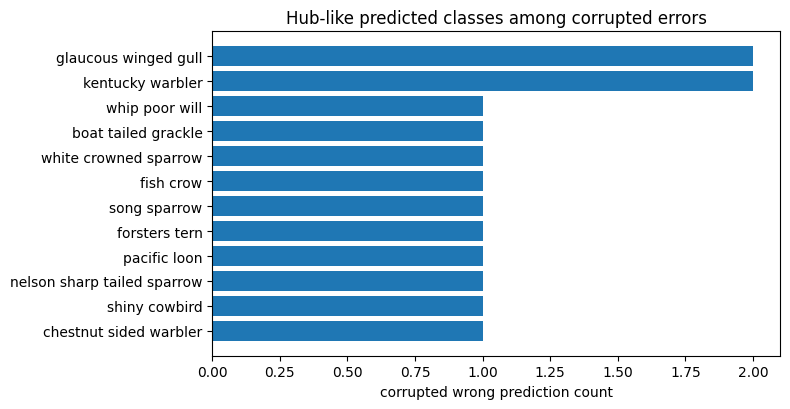

In [9]:
if len(hub) > 0:
    top_hub = hub.head(12).iloc[::-1]
    plt.figure(figsize=(8, max(3, 0.35 * len(top_hub))))
    plt.barh(top_hub["pred_label"], top_hub["count"])
    plt.xlabel("corrupted wrong prediction count")
    plt.title("Hub-like predicted classes among corrupted errors")
    plt.tight_layout()
    plt.show()
else:
    print("Corrupted 오분류가 없어 hub 집계가 비어 있습니다. N_SAMPLES를 늘리거나 severity를 올려보세요.")

## 이미지별 원본/손상 비교

아래 grid는 각 샘플의 원본과 corruption 적용 이미지를 나란히 보여줍니다.

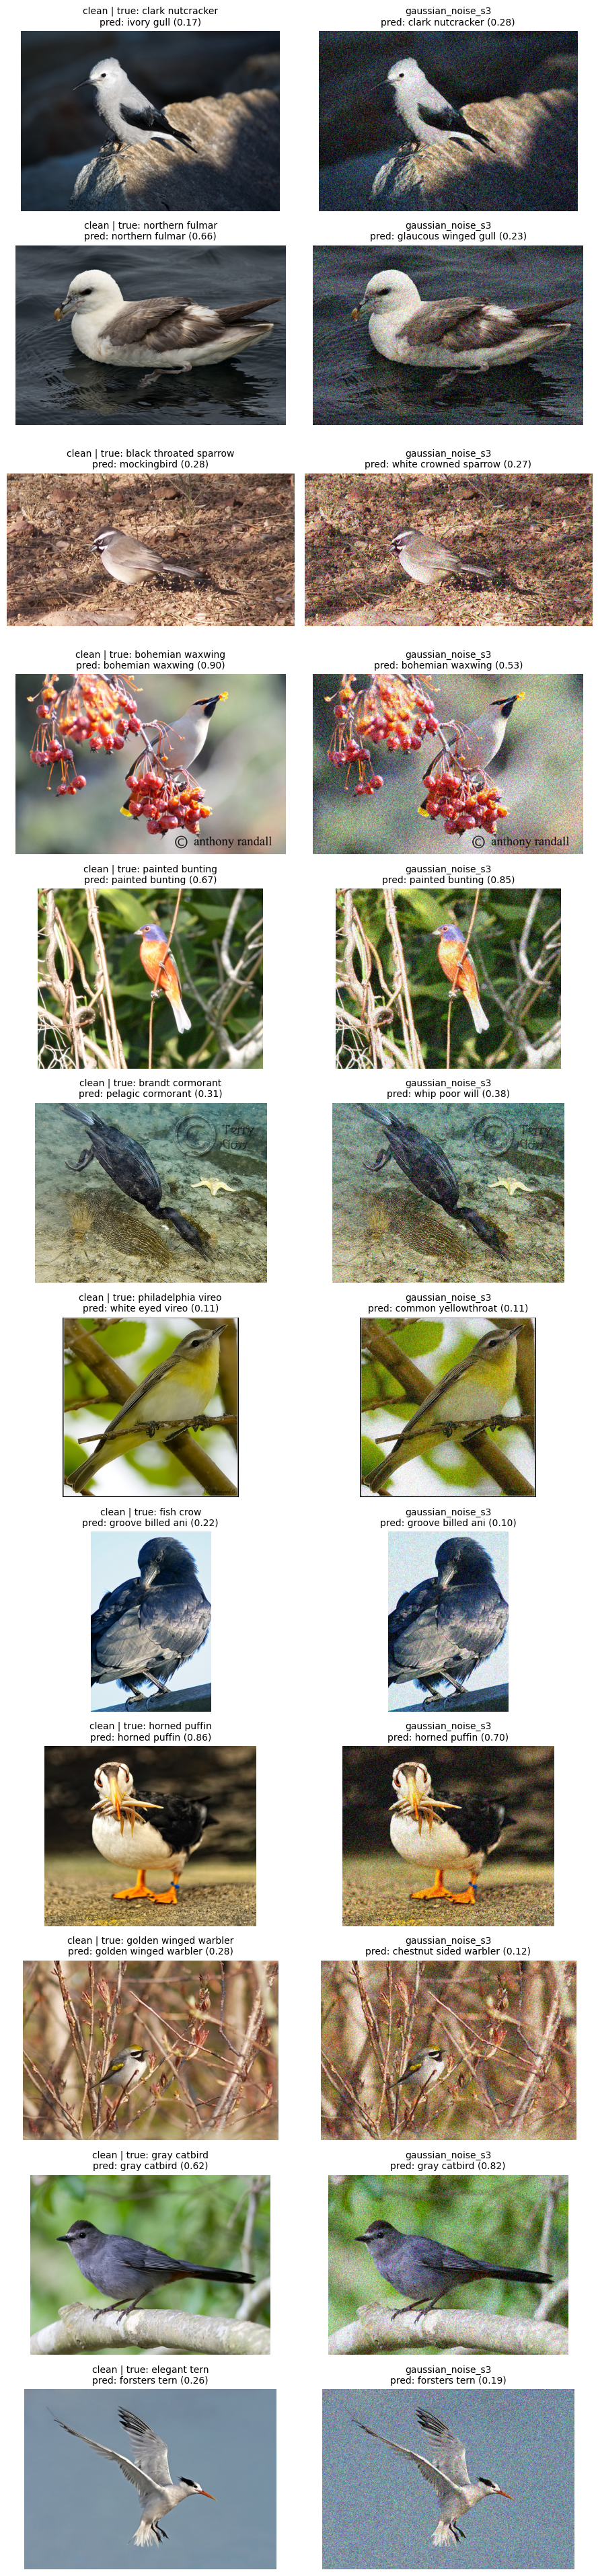

In [10]:
def short_label(text, max_len=28):
    return text if len(text) <= max_len else text[: max_len - 3] + "..."


n_show = min(12, len(preview_images))
fig, axes = plt.subplots(n_show, 2, figsize=(9, 3.2 * n_show))
if n_show == 1:
    axes = np.array([axes])

for row_idx, item in enumerate(preview_images[:n_show]):
    clean_pred = item["clean_pred"]
    corr_pred = item["corrupted_pred"]
    true_label = item["true_label"]

    clean_title = f"clean | true: {short_label(true_label)}\npred: {short_label(clean_pred['pred_label'])} ({clean_pred['confidence']:.2f})"
    corr_title = f"{corr_condition}\npred: {short_label(corr_pred['pred_label'])} ({corr_pred['confidence']:.2f})"

    axes[row_idx, 0].imshow(item["clean_image"])
    axes[row_idx, 0].set_title(clean_title, fontsize=10)
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(item["corrupted_image"])
    axes[row_idx, 1].set_title(corr_title, fontsize=10)
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

## 특정 샘플 top-k 자세히 보기

In [11]:
SAMPLE_ID_TO_INSPECT = int(wide.sort_values("confidence_delta", ascending=False).iloc[0].sample_id)

detail = df[df.sample_id == SAMPLE_ID_TO_INSPECT][["condition", "true_label", "pred_label", "confidence", "topk"]]
display(detail.drop(columns=["topk"]).style.format({"confidence": "{:.3f}"}))

for _, row in detail.iterrows():
    print(f"\n[{row.condition}] true={row.true_label}")
    for rank, (label, prob) in enumerate(row.topk, start=1):
        print(f"  {rank}. {label:30s} {prob:.4f}")

,condition,true_label,pred_label,confidence
20,clean,gray catbird,gray catbird,0.623
21,gaussian_noise_s3,gray catbird,gray catbird,0.824



[clean] true=gray catbird
  1. gray catbird                   0.6234
  2. dark eyed junco                0.0597
  3. spotted catbird                0.0412
  4. gray kingbird                  0.0382
  5. olive sided flycatcher         0.0325

[gaussian_noise_s3] true=gray catbird
  1. gray catbird                   0.8244
  2. dark eyed junco                0.0425
  3. spotted catbird                0.0202
  4. brewer blackbird               0.0120
  5. clark nutcracker               0.0120
